In [1]:
import src.data as data
import src.testes as testes
import src.viz as viz
import src.models as models

In [2]:
caminho_train = "dados/treino.csv"
caminho_val = "dados/validacao.csv"

data_fim_train = "2016-03-27"

data_inicio_val = "2016-03-28"
data_fim_val = "2016-04-24"

In [3]:
train_data = data.carregar_dados_e_tratar_data(
    caminho=caminho_train, data_fim=data_fim_train
)
validation_data = data.carregar_dados_e_tratar_data(
    caminho=caminho_val, data_inicio=data_inicio_val, data_fim="2016-04-24"
)

In [4]:
print(train_data.head())

        date  store_total  FOODS  HOBBIES
0 2011-01-29         4337   3239      556
1 2011-01-30         4155   3137      498
2 2011-01-31         2816   2008      415
3 2011-02-01         3051   2258      392
4 2011-02-02         2630   2032      268


In [5]:
print(validation_data.head())

        date  store_total  FOODS  HOBBIES
0 2016-03-28         3905   2480      535
1 2016-03-29         3788   2481      498
2 2016-03-30         3339   2135      465
3 2016-03-31         4076   2651      536
4 2016-04-01         4983   3132      743


In [6]:
testes.verificar_consistencia(
    train_data,
    validation_data,
    data_fim1=data_fim_train,
    data_inicio2=data_inicio_val,
    data_fim2=data_fim_val,
)

SUCESSO: Os dados estão consistentes (Do tipo correto, ordenados, com datas únicas, no intervalo correto e sem vazamentos)


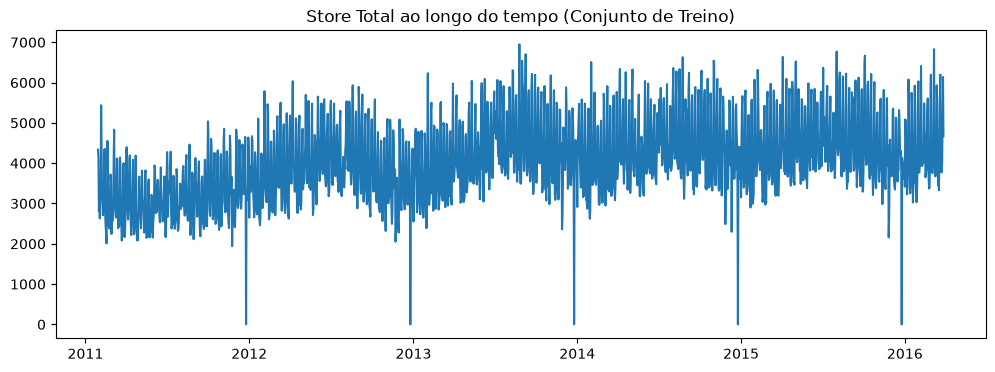

In [7]:
viz.grafico_temporal(
    train_data["store_total"],
    train_data["date"],
    titulo="Store Total ao longo do tempo (Conjunto de Treino)",
    data_inicio=None,
    data_fim=None,
)

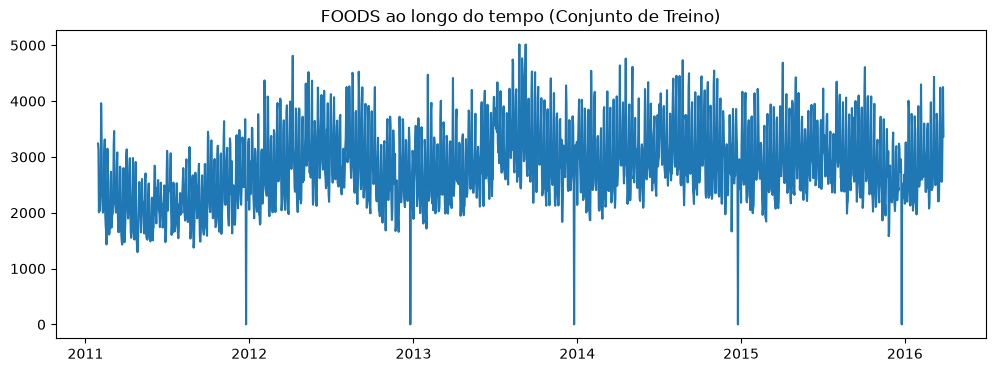

In [8]:
viz.grafico_temporal(
    train_data["FOODS"],
    train_data["date"],
    titulo="FOODS ao longo do tempo (Conjunto de Treino)",
    data_inicio=None,
    data_fim=None,
)

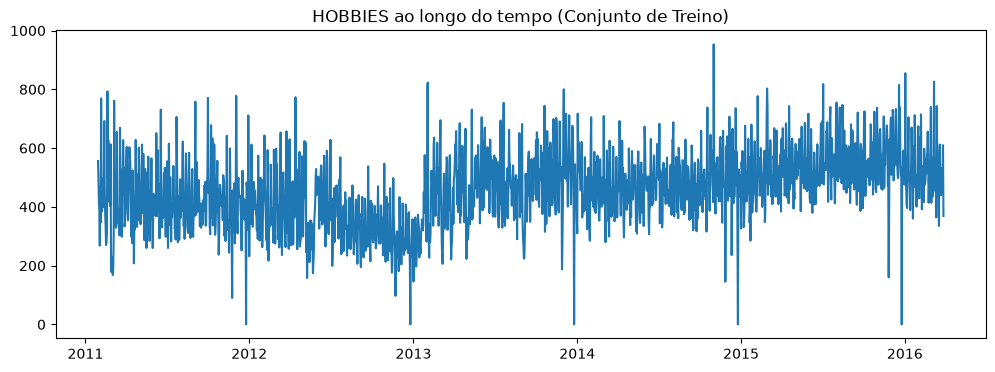

In [9]:
viz.grafico_temporal(
    train_data["HOBBIES"],
    train_data["date"],
    titulo="HOBBIES ao longo do tempo (Conjunto de Treino)",
    data_inicio=None,
    data_fim=None,
)

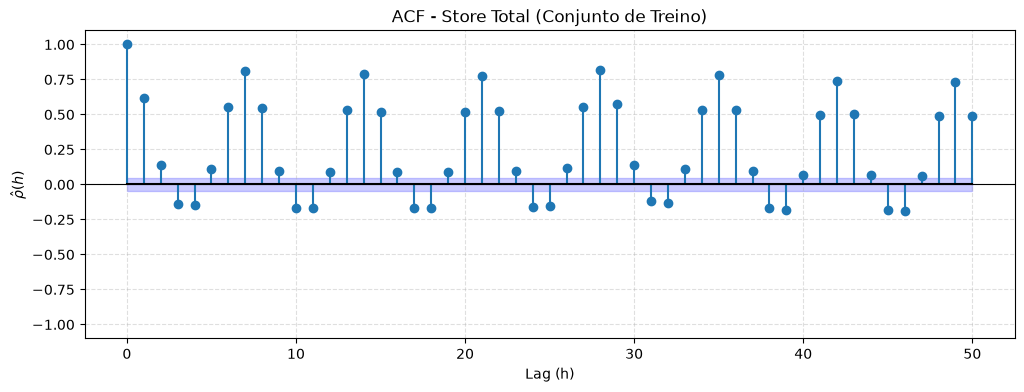

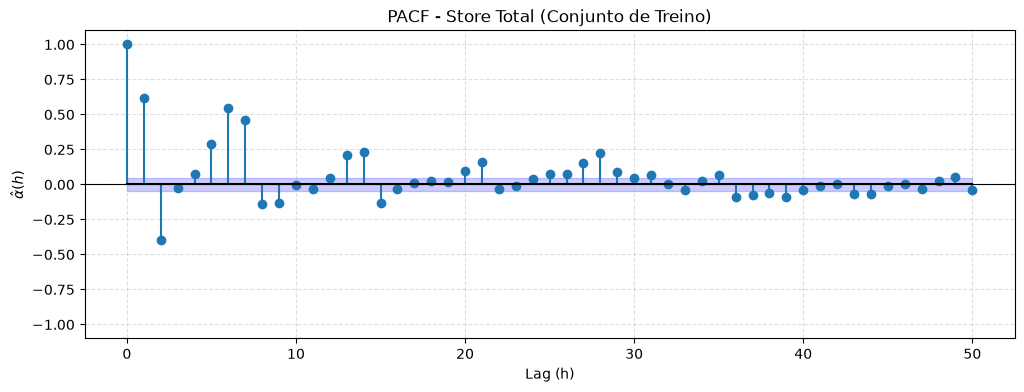

In [10]:
# ACF e PACF para o Store Total no conjunto de treino

viz.grafico_ACF(
    train_data["store_total"],
    train_data["date"],
    titulo="ACF - Store Total (Conjunto de Treino)",
    data_inicio=None,
    data_fim=None,
    nlags=50,
)

viz.grafico_PACF(
    train_data["store_total"],
    train_data["date"],
    titulo="PACF - Store Total (Conjunto de Treino)",
    data_inicio=None,
    data_fim=None,
    nlags=50,
)

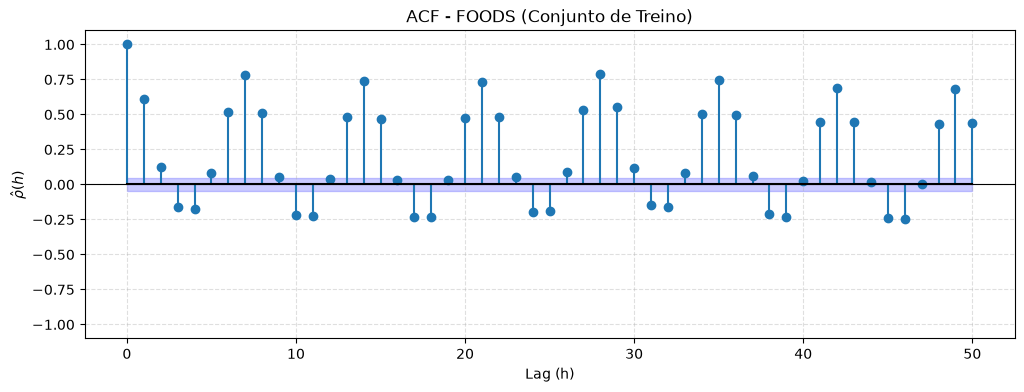

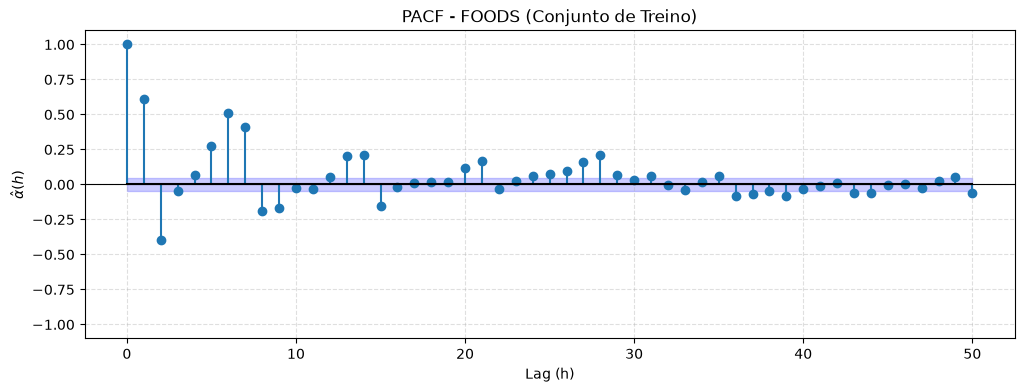

In [11]:
# ACF e PACF para a categoria FOODS no conjunto de treino

viz.grafico_ACF(
    train_data["FOODS"],
    train_data["date"],
    titulo="ACF - FOODS (Conjunto de Treino)",
    data_inicio=None,
    data_fim=None,
    nlags=50,
)

viz.grafico_PACF(
    train_data["FOODS"],
    train_data["date"],
    titulo="PACF - FOODS (Conjunto de Treino)",
    data_inicio=None,
    data_fim=None,
    nlags=50,
)

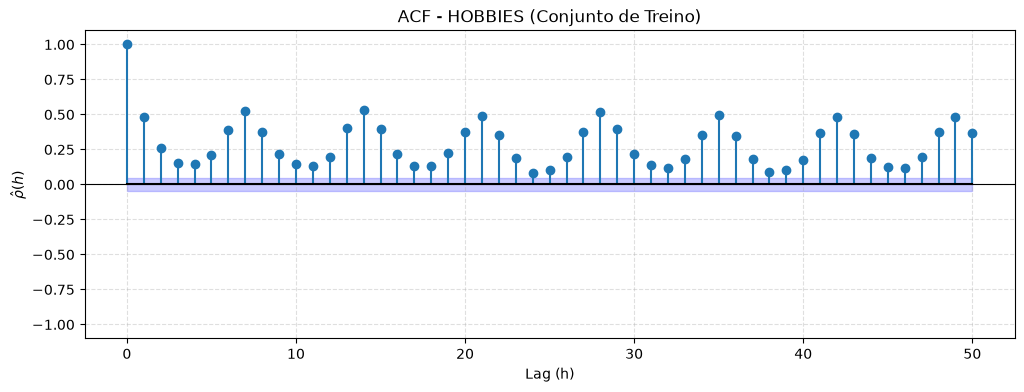

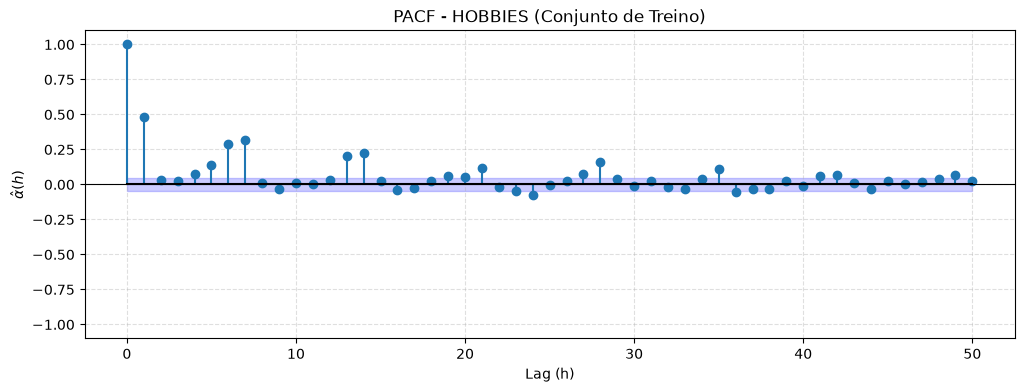

In [12]:
# ACF e PACF para a categoria HOOBIES no conjunto de treino

viz.grafico_ACF(
    train_data["HOBBIES"],
    train_data["date"],
    titulo="ACF - HOBBIES (Conjunto de Treino)",
    data_inicio=None,
    data_fim=None,
    nlags=50,
)

viz.grafico_PACF(
    train_data["HOBBIES"],
    train_data["date"],
    titulo="PACF - HOBBIES (Conjunto de Treino)",
    data_inicio=None,
    data_fim=None,
    nlags=50,
)

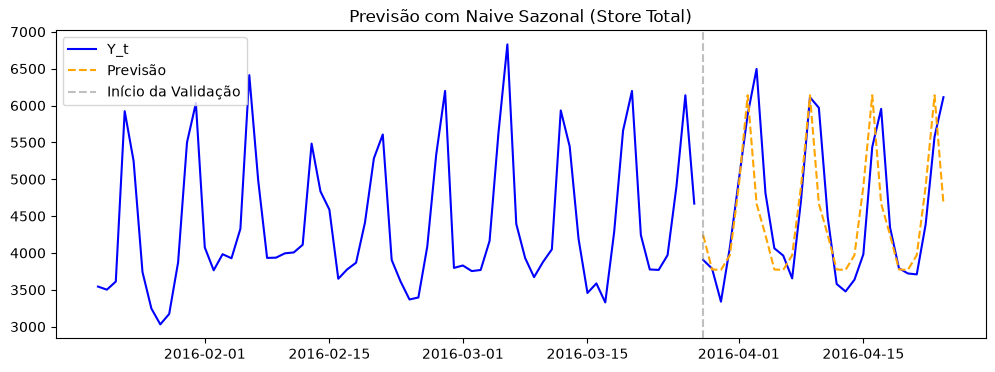

In [ ]:
# Previsão com Naive Sazonal - Store Total
Y_prev_total = models.naive_sazonal(train_data["store_total"], m=7, n=len(validation_data))

viz.grafico_temporal_com_previsao(
    train_data["store_total"],
    train_data["date"],
    validation_data["store_total"],
    validation_data["date"],
    Y_prev_total,
    validation_data["date"],
    titulo="Previsão com Naive Sazonal (Store Total)",
    data_inicio="2016-01-20",
    data_fim=None,
)

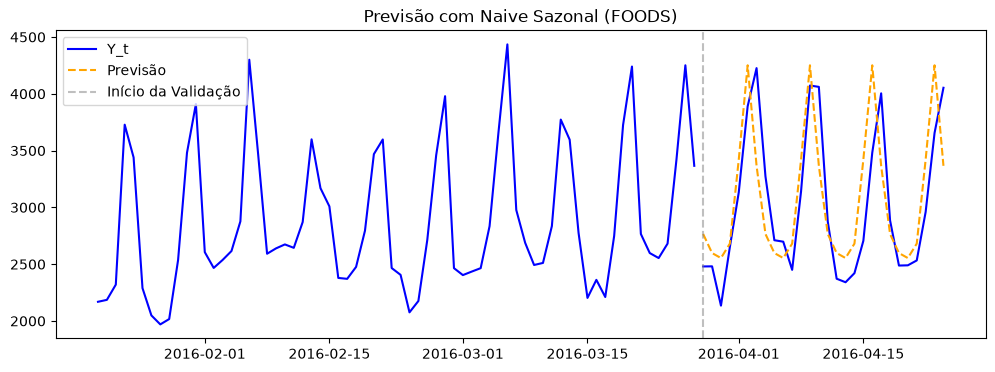

In [ ]:
# Previsão com Naive Sazonal - Foods
Y_prev_foods = models.naive_sazonal(train_data["FOODS"], m=7, n=len(validation_data))

viz.grafico_temporal_com_previsao(
    train_data["FOODS"],
    train_data["date"],
    validation_data["FOODS"],
    validation_data["date"],
    Y_prev_foods,
    validation_data["date"],
    titulo="Previsão com Naive Sazonal (FOODS)",
    data_inicio="2016-01-20",
    data_fim=None,
)

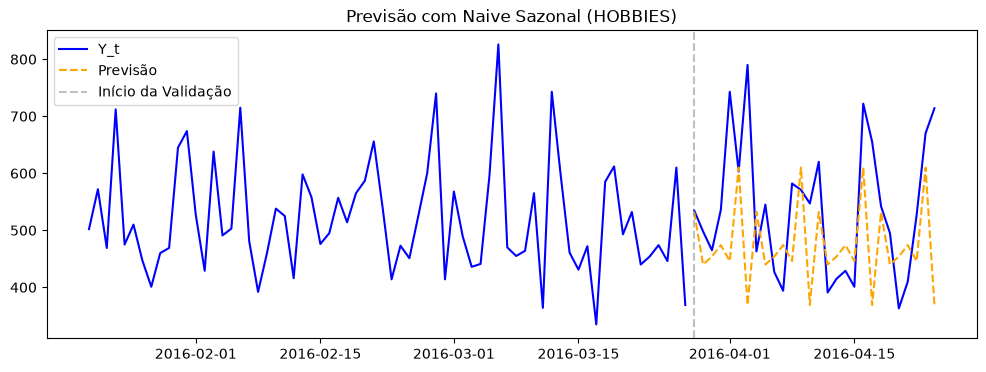

In [19]:
# Previsão com Naive Sazonal - Hobbies
Y_prev_foods = models.naive_sazonal(train_data["HOBBIES"], m=7, n=len(validation_data))

viz.grafico_temporal_com_previsao(
    train_data["HOBBIES"],
    train_data["date"],
    validation_data["HOBBIES"],
    validation_data["date"],
    Y_prev_foods,
    validation_data["date"],
    titulo="Previsão com Naive Sazonal (HOBBIES)",
    data_inicio="2016-01-20",
    data_fim=None,
)